In [1]:
local_path = "/Users/ravirajan/Projects/Demographics/debug"

In [2]:
li_path = "s3://sharethis-data-in-liveintent/hem-demo/20251001/"
my_demo_path = "s3://data-science-research/ravi/demographics/skewed"

## NEED AWS creds ready for this

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "s3fs", "-q"], check=True)

import pyarrow.dataset as ds
import pyarrow.parquet as pq
import s3fs, os

fs = s3fs.S3FileSystem()  # picks up AWS_* env vars from refresh_aws()

output_path = "/Users/ravirajan/Projects/Demographics/debug"
bucket_prefix = "data-science-research/ravi/demographics/skewed"

datasets = [
    "sovrn_estid_behavioral",
    "sovrn_estid_demo_after_join",
    "sovrn_estid_demo_clean_final",
    "sovrn_estid_behavioral_clean_final"
    "sovrn_estid_demo_clean_final_index", # this is just LI data, name may change in future
]

for name in datasets:
    local_dir = f"{output_path}/{name}"
    os.makedirs(local_dir, exist_ok=True)
    table = ds.dataset(f"{bucket_prefix}/{name}", filesystem=fs).head(1_000_000)
    pq.write_table(table, f"{local_dir}/part0.parquet")
    print(f"Saved {name}: {len(table)} rows")


In [46]:
import pyarrow.dataset as ds

n=100000

behavioral_raw = ds.dataset(f"{local_path}/sovrn_estid_behavioral").head(n).to_pandas()
#behavioral_clean = ds.dataset(f"{local_path}/sovrn_estid_behavioral_clean_final").head(1_000_000).to_pandas()
demo_after_join = ds.dataset(f"{local_path}/sovrn_estid_demo_after_join").head(n).to_pandas()
#demo_clean = ds.dataset(f"{local_path}/sovrn_estid_demo_clean_final_index").head(1_000_000).to_pandas()
li = ds.dataset(f"{local_path}/li_hem_demo_index").head(n).to_pandas()

In [222]:
behavioral_raw.head()

,estid,domain,count
0,ZGmAB2g9mKQAAAAIA7coAw==,Other,6
1,ZGLABWfsYUgAAAAIFvM5Aw==,35mmc.com,1
2,ZGEACWc0E4EAAAAIXBbwAw==,Other,16
3,ZH4AA2cNnWkAAAAJBlDZAw==,Other,10
4,ZGEAAGcOnBQAAAAIBJCFAw==,aiptcomics.com,12


In [223]:
demo_after_join.head()

,estid,age_index,income_index,gender_index,home_owner_index,marital_status_index,net_worth_hh_index,occupation_category_index,dwelling_type_index,education_index,...,amex_card_index,cat_owner_index,children_hh_index,credit_card_index,dog_owner_index,owns_investments_index,pet_owner_index,premium_amex_card_index,premium_card_index,owns_stocks_and_bonds_index
0,CgsA5WkG2MkAAAAJPROgAw==,5.0,3.0,1,0.0,0.0,6.0,2.0,0.0,4.0,...,0,1,0,1,1,1,1,0,1,0
1,CgsA5WkG2ioAAAAJPZrIAw==,5.0,1.0,0,0.0,1.0,8.0,NaN,0.0,2.0,...,0,1,0,1,1,1,1,1,1,1
2,CgsA5WkGbm4AAAAJDm6rAw==,2.0,4.0,1,0.0,1.0,5.0,NaN,0.0,2.0,...,0,0,1,1,1,1,1,0,1,0
3,CgsA5WkGdScAAAAJEWYvAw==,4.0,5.0,0,0.0,1.0,7.0,1.0,1.0,2.0,...,0,0,1,1,0,1,0,0,1,0
4,CgsA5WkGuWwAAAAJLwalAw==,4.0,5.0,0,0.0,1.0,8.0,0.0,0.0,2.0,...,1,1,1,1,1,1,1,0,0,0


In [231]:
li.head()

,hem_md5,age_index,income_index,gender_index,home_owner_index,marital_status_index,net_worth_hh_index,occupation_category_index,dwelling_type_index,education_index,...,amex_card_index,cat_owner_index,children_hh_index,credit_card_index,dog_owner_index,owns_investments_index,pet_owner_index,premium_amex_card_index,premium_card_index,owns_stocks_and_bonds_index
0,0876bc7da973f26f32b01bc1e0230990,5.0,4.0,1,0.0,0.0,8.0,3.0,0.0,4.0,...,1,1,1,1,1,1,1,0,1,1
1,4f6ef7a210aff46a031d96ad6b30db9f,5.0,4.0,1,0.0,0.0,8.0,3.0,0.0,4.0,...,1,1,1,1,1,1,1,0,1,1
2,e272b5fa15dd045e73fcfa88d1ca1ff9,5.0,4.0,1,0.0,0.0,8.0,3.0,0.0,4.0,...,1,1,1,1,1,1,1,0,1,1
3,b877a62b6f215faa0af955273ac0a142,5.0,4.0,1,0.0,0.0,8.0,3.0,0.0,4.0,...,1,1,1,1,1,1,1,0,1,1
4,None,5.0,4.0,1,0.0,0.0,8.0,3.0,0.0,4.0,...,1,1,1,1,1,1,1,0,1,1


In [27]:
import pickle
import pandas as pd
import numpy as np
import glob
import scipy.stats
import BayesBoom.R as R
import matplotlib.pyplot as plt
import BayesBoom.factormodels as fm

In [201]:
def find_parameter_starting_values(behavioral, demographic, category_var_name):
    joined_data = behavioral.join(demographic, on="estid")
    global_intensity = joined_data.groupby("category_var_name")["count"].sum()
    cat_counts = demographic["category_var_name"].value_counts()
    all_domains = behavioral["domain"].unique()
    num_domains = len(all_domains)
    
    global_intensity = global_intensity / cat_counts / num_domains
    local_intensity_groups = joined_data.groupby(
        ["domain", "category_var_name"])["count"].sum()
    local_intensity = {}
    for x in all_domains:
        local_intensity[x] = local_intensity_groups[x].reindex(
            global_intensity.index, fill_value=0) / cat_counts
        local_intensity[x] = .9 * local_intensity[x] + .1 * global_intensity
    return local_intensity


def get_cat_distribution(demographic,
                         category_var_name,
                         min_traffic=0,
                         max_traffic=None,
                         behavioral=None,
                         num_cat_buckets=None,
    ):
    """Generate empirical distribution. Can be used as Prior.

    Args:
        num_cat_buckets: override the number of category levels. Pass
            model.nlevels when computing a prior for an already-trained model
            so the vector length matches even if the source data (e.g. LI) has
            a lower max category value than the training data.

    Returns:
        num_cat_buckets    — total number of category levels
        cat_distribution   — Laplace-smoothed empirical class prior (numpy array)
    """
    if num_cat_buckets is None:
        num_cat_buckets = int(demographic[category_var_name].max()) + 1

    if max_traffic is not None and behavioral is not None:
        traffic_counts = behavioral.groupby("estid")["count"].sum()
        keep = (traffic_counts >= min_traffic) & (traffic_counts <= max_traffic)
        demo_subset = demographic[demographic.index.isin(set(keep.index))]
        print(f"filter demographic {min_traffic} <= traffic_counts <= {max_traffic}")
    else:
        demo_subset = demographic
    cat_demo = demo_subset[category_var_name]
    
    # Laplace smoothing so absent classes get a small non-zero prior weight
    counts = cat_demo.value_counts().reindex(range(num_cat_buckets), fill_value=0) + 1
    cat_distribution = (counts / counts.sum()).to_numpy()
    print(f"num_cat_buckets={num_cat_buckets}  cat_distribution={cat_distribution.round(3)}")
    return num_cat_buckets, cat_distribution

    
def prepare_training_data(
    behavioral,
    demographic,
    min_traffic,
    max_traffic,
    percent_holdout,
    category_var_name="age_index",
    traffic_winsorize=np.inf,
    focus_users=["ZHMAAWSoy1wAAAAIRObzAw=="],
    ):
    """Filter behavioral/demographic data and produce a train/holdout split.

    Returns:
        behavioral_subset  — filtered behavioral rows (no null domains)
        demo_subset        — demographic rows for users passing traffic filter
        cat_demo           — training-split category labels (indexed by estid)
        cat_holdout        — holdout-split category labels (indexed by estid)
    """
    traffic_counts = behavioral.groupby("estid")["count"].sum()
    keep = (traffic_counts >= min_traffic) & (traffic_counts <= max_traffic)

    behavioral_subset = behavioral[
        behavioral["estid"].isin(set(keep.index)) &
        behavioral["domain"].notna()
    ].copy()
    too_big = behavioral_subset["count"] > traffic_winsorize
    behavioral_subset.loc[too_big, "count"] = traffic_winsorize

    demo_subset = demographic[demographic.index.isin(set(keep.index))]

    holdout_size = int(percent_holdout * len(demo_subset))
    holdout_estids = list(np.random.choice(traffic_counts.index, size=holdout_size))
    for estid in focus_users:
        if estid not in holdout_estids:
            holdout_estids.append(estid)
    holdout_estids = np.array(holdout_estids)

    cat_holdout = demo_subset[demo_subset.index.isin(holdout_estids)][category_var_name]
    cat_demo    = demo_subset[~demo_subset.index.isin(holdout_estids)][category_var_name]

    print(f"users: {len(demo_subset)} total, {len(cat_demo)} train, {len(cat_holdout)} holdout")    

    return behavioral_subset, demo_subset, cat_demo, cat_holdout


def fit_model(niter, behavioral_subset, cat_demo, num_cat_buckets, cat_distribution,
              family="multinomial", flat_prior=False):
    """Fit a BayesBoom factor model from prepared training inputs.

    Args:
        niter              — number of MCMC iterations
        behavioral_subset  — behavioral rows (estid / domain / count, no nulls)
        cat_demo           — training-split category labels (pd.Series indexed by estid)
        num_cat_buckets    — total number of category levels
        cat_distribution   — empirical class prior as a numpy array of length num_cat_buckets
        family             — "multinomial" or "poisson"
        flat_prior         — if True, use a uniform user class prior

    Returns:
        Fitted model object (MCMC draws stored in _site_draws).
    """
    if family == "poisson":
        model = fm.PoissonFactorModel(num_cat_buckets)
    elif family == "multinomial":
        model = fm.MultinomialFactorModel(num_cat_buckets)
    else:
        raise Exception(f"'family' must be 'poisson' or 'multinomial'. Got: {family}")

    if not flat_prior:
        model.set_default_user_prior(cat_distribution)
        plt.bar(range(num_cat_buckets), cat_distribution)

    model.add_data(user=behavioral_subset["estid"],
                   site=behavioral_subset["domain"],
                   count=behavioral_subset["count"])
    # cast to int: parquet stores nullable int columns as float64 (due to NaN),
    # and BayesBoom's _assign_sampler uses these as array indices
    model.set_known_user_demographics(cat_demo.astype(int))
    model.omit_data_when_serializing()

    model.run_mcmc(niter, ping=1)
    return model

def save_model(model, attr, model_path):
    os.makedirs("/tmp/ravi_demo_test", exist_ok=True)
    with open(f"/tmp/ravi_demo_test/{attr}_model.pkl", "wb") as f:
      pickle.dump(model, f)
    os.makedirs(model_path, exist_ok=True)
    shutil.copy(f"/tmp/ravi_demo_test/{attr}_model.pkl", f"{model_path}/{attr}_model.pkl")


## PRED FNs

def process_model(attr, partition, path, prior=None):
    with open(f"{path}/{attr}_model.pkl", "rb") as f:
        model = pickle.load(f)

    print(f"processing {path}/{attr}_model.pkl")
    behavior = pd.DataFrame(partition, columns=["estid", "domain", "count"])
    behavior = behavior.dropna(subset=["estid", "domain"])

    if prior is not None:
        print("overriding prior")
        model.set_default_user_prior(prior)
    
    posterior_distribution = model.infer_posterior_distributions(
        behavior["estid"].astype(str), behavior["domain"].astype(str))

    return posterior_distribution


def infer_by_attribute(partition, demo_attributes, path):
    partition_data = list(partition)
    result = pd.DataFrame()

    for attr in demo_attributes:
        posterior_distribution = process_model(attr, partition_data, path)
        result = pd.concat([result, posterior_distribution], axis=1)

    transformed_data = list(result.itertuples(index=True, name=None))
    return transformed_data

In [29]:
import os

def store_counts(df, attr, path):
    counts = df.groupby(f"{attr}").size().reset_index(name="count")
    os.makedirs(path, exist_ok=True)
    counts.to_json(f"{path}/{attr}_counts.json", orient="records")

/var/folders/wt/bzrqdlb17zv7h4r1y9jqpg_w0000gp/T/ipykernel_16740/2713390515.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'inf' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  behavioral_subset.loc[too_big, "count"] = traffic_winsorize


users: 1208 total, 1208 train, 0 holdout
filter demographic 0 <= traffic_counts <= inf
num_cat_buckets=6  cat_distribution=[0.06  0.105 0.115 0.167 0.199 0.353]
Adding data to the boom model.
Done with chunks.  Adding final piece with 1383 rows.
Done adding data!
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:05 2026 Iteration 0  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:05 2026 Iteration 1  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:05 2026 Iteration 2  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:05 2026 Iteration 3  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:05 2026 Iteration 4  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:05 2026 Iteration 5  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:05 2026 Iteration 6  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:05 2026 Iteration 7  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:05 2026 Iteration 8  =-=

/var/folders/wt/bzrqdlb17zv7h4r1y9jqpg_w0000gp/T/ipykernel_16740/2713390515.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'inf' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  behavioral_subset.loc[too_big, "count"] = traffic_winsorize


 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:07 2026 Iteration 24  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:07 2026 Iteration 25  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:07 2026 Iteration 26  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:07 2026 Iteration 27  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:07 2026 Iteration 28  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:07 2026 Iteration 29  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:07 2026 Iteration 30  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:07 2026 Iteration 31  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:07 2026 Iteration 32  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:07 2026 Iteration 33  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:07 2026 Iteration 34  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:07 2026 Iteration 35  =-=

/var/folders/wt/bzrqdlb17zv7h4r1y9jqpg_w0000gp/T/ipykernel_16740/2713390515.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'inf' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  behavioral_subset.loc[too_big, "count"] = traffic_winsorize


...

 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:16 2026 Iteration 82  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:16 2026 Iteration 83  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:16 2026 Iteration 84  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:16 2026 Iteration 85  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:16 2026 Iteration 86  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:16 2026 Iteration 87  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:16 2026 Iteration 88  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:16 2026 Iteration 89  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:16 2026 Iteration 90  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:16 2026 Iteration 91  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:16 2026 Iteration 92  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:16 2026 Iteration 93  =-=

/var/folders/wt/bzrqdlb17zv7h4r1y9jqpg_w0000gp/T/ipykernel_16740/2713390515.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'inf' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  behavioral_subset.loc[too_big, "count"] = traffic_winsorize


 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:17 2026 Iteration 44  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:17 2026 Iteration 45  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:17 2026 Iteration 46  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:17 2026 Iteration 47  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:17 2026 Iteration 48  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:17 2026 Iteration 49  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:17 2026 Iteration 50  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:17 2026 Iteration 51  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:17 2026 Iteration 52  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:17 2026 Iteration 53  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:17 2026 Iteration 54  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:17 2026 Iteration 55  =-=

/var/folders/wt/bzrqdlb17zv7h4r1y9jqpg_w0000gp/T/ipykernel_16740/2713390515.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'inf' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  behavioral_subset.loc[too_big, "count"] = traffic_winsorize


users: 225 total, 225 train, 0 holdout
filter demographic 0 <= traffic_counts <= inf
num_cat_buckets=7  cat_distribution=[0.004 0.405 0.573 0.004 0.004 0.004 0.004]
Adding data to the boom model.
Done with chunks.  Adding final piece with 258 rows.
Done adding data!
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:19 2026 Iteration 0  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:19 2026 Iteration 1  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:19 2026 Iteration 2  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:19 2026 Iteration 3  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:19 2026 Iteration 4  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:19 2026 Iteration 5  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:19 2026 Iteration 6  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:19 2026 Iteration 7  =-=-=-=-=-=-=-=-=-=-= 
 =-=-=-=-=-=-=-=-=-=-= Thu May 28 17:51:19 2026 Iteration 8  

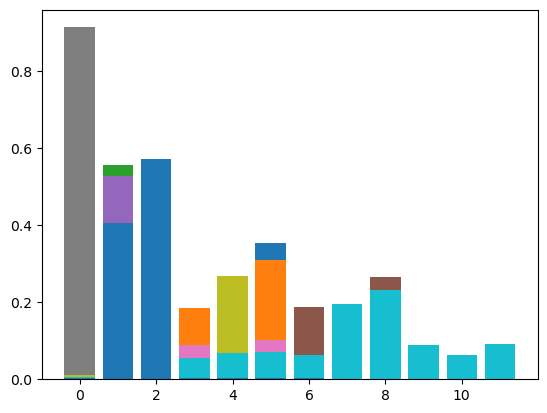

In [194]:
import shutil

attributes = ["income", "age", "gender", "home_owner", "marital_status", "net_worth_hh", "occupation_category", "dwelling_type", "education", "income_hh", "political_party"]

#attributes = ["age", "gender"]

#attributes = [
#    "amex_card",
#    "cat_owner",
#    "children_hh",
#    "credit_card",
#    "dog_owner",
#    "owns_investments",
#    "pet_owner",
#    "premium_amex_card",
#    "premium_card",
#    "owns_stocks_and_bonds"
#]


max_traffic=1000

demo_attributes = [f"{attr}_index" for attr in attributes]

#demo_attributes = ['gender_index']
demo_out_path = f"{local_path}/outputs"
model_path = f"{demo_out_path}/models"
demographics = demo_after_join
behavioral = behavioral_raw

model_outs = {}

for attr in demo_attributes:

  demo = demographics[demographics[attr].isna() == False].copy()
  demo.set_index("estid", inplace=True)
  #print(demo.head())

  # store the joined (training) counts
  store_counts(demo, attr, f"{demo_out_path}/joined_data_counts/")

  # make sure behavior and demo have the same users
  behavior = behavioral[behavioral["estid"].isin(demo.index)]

  behavioral_subset, demo_subset, cat_demo, cat_holdout = prepare_training_data(
      behavior, demo,
      min_traffic=0, max_traffic=max_traffic, percent_holdout=0, category_var_name=attr) 
    # percent_holdout=0.1


  #num_cat_buckets, cat_distribution = get_cat_distribution(demographic=demo, category_var_name=attr,
  #                                                         min_traffic=0, max_traffic=max_traffic, behavioral=behavior)

  num_cat_buckets, cat_distribution = get_cat_distribution(demographic=demo, category_var_name=attr,
                                                           min_traffic=0, max_traffic=np.inf, behavioral=behavior)

  #num_cat_buckets, cat_distribution = get_cat_distribution(demographic=li, category_var_name=attr,
  #                                                         min_traffic=0, max_traffic=np.inf, behavioral=None)
    
  model = fit_model(1000, behavioral_subset, cat_demo, num_cat_buckets, cat_distribution,
                    family="multinomial", flat_prior=False)

  model_outs[attr] = {
      'model':            model,
      'holdout':          cat_holdout,
      'demo_train':       demo_subset,
      'demo_cat':         cat_demo,
      'behavioral_train': behavioral_subset,
  }

  # save model
  save_model(model, attr, model_path)

  # store the filtered (training) counts
  store_counts(demo_subset, attr, f"{demo_out_path}/filtered_data_counts/")

In [175]:
behavior.head()

,estid,domain,count
567,ZHEABWhEKNIAAAAIBObtAw==,motor1.com,1
1663,ZHkACmccTagAAAAIG9t3Aw==,wftv.com,1
1929,ZHqABWfY1kQAAAAIUH2lAw==,beetlejuice.fandom.com,2
2051,ZG4AC2flfVgAAAAIBG7OAw==,emathhelp.net,3
2424,ZGcACmg8w1sAAAAIIUncAw==,recipereader.com,2


In [8]:
# prediction

# Apply the inference function on the full dataset
#result_rows = infer_by_attribute(behavioral[["estid", "domain", "count"]].itertuples(index=False, name=None), demo_attributes, model_path)
#posterior_distributions_df = pd.DataFrame(result_rows)

#print(posterior_distributions_df.head(100))

In [9]:
#pd.DataFrame(model_outs['gender_index']['holdout'])

In [10]:
#pd.DataFrame(model_outs['home_owner_index']['holdout'])

In [65]:
#li.head()

In [150]:
len(li)

100000

In [202]:
cmp = {}
cmp_counts = {}

for attr in demo_attributes:
    dat_train = model_outs[attr]['behavioral_train']
    demo_train = model_outs[attr]['demo_train']
    demo_cat = pd.DataFrame(model_outs[attr]['demo_cat'])
    posterior = process_model(attr, dat_train, model_path)

    trained_model = model_outs[attr]['model']
    _, cat_distribution_li = get_cat_distribution(demographic=li, category_var_name=attr,
                                    min_traffic=0, max_traffic=np.inf, behavioral=None,
                                    num_cat_buckets=trained_model.nlevels)
    posterior_new = process_model(attr, dat_train, model_path, prior=cat_distribution_li)
    
    cmp[attr] = {
        'li': dict(li.groupby(attr).size() / len(li)),
        'estid' : dict(demographics.groupby(attr).size() / len(demographics)),
        'pred': dict(posterior.mean()),
        'pred_new': dict(posterior_new.mean()),
        'train': dict(demo_train.groupby(attr).size() / len(demo_train)),
        'prior': dict(demo_cat.groupby(attr).size() / len(demo_cat)),
    }
    cmp_counts[attr] = {
        'li': dict(li.groupby(attr).size()),
        'estid' : dict(demographics.groupby(attr).size()),
        'pred': dict(posterior.mean() * len(posterior)),
        'pred_new': dict(posterior_new.mean() * len(posterior_new)),
        'train': dict(demo_train.groupby(attr).size()),
        'prior': dict(demo_cat.groupby(attr).size()),
    }

processing /Users/ravirajan/Projects/Demographics/debug/outputs/models/income_index_model.pkl
i = 0 of 1208
i = 1000 of 1208
num_cat_buckets=6  cat_distribution=[0.095 0.139 0.127 0.167 0.188 0.283]
processing /Users/ravirajan/Projects/Demographics/debug/outputs/models/income_index_model.pkl
overriding prior
i = 0 of 1208
i = 1000 of 1208
processing /Users/ravirajan/Projects/Demographics/debug/outputs/models/age_index_model.pkl
i = 0 of 1193
i = 1000 of 1193
num_cat_buckets=6  cat_distribution=[0.007 0.063 0.163 0.211 0.224 0.332]
processing /Users/ravirajan/Projects/Demographics/debug/outputs/models/age_index_model.pkl
overriding prior
i = 0 of 1193
i = 1000 of 1193
processing /Users/ravirajan/Projects/Demographics/debug/outputs/models/gender_index_model.pkl
i = 0 of 1238
i = 1000 of 1238
num_cat_buckets=2  cat_distribution=[0.48 0.52]
processing /Users/ravirajan/Projects/Demographics/debug/outputs/models/gender_index_model.pkl
overriding prior
i = 0 of 1238
i = 1000 of 1238
processin

In [203]:
pd.DataFrame(cmp['gender_index']).round(2)

,li,estid,pred,pred_new,train,prior
0,0.48,0.44,0.45,0.46,0.44,0.44
1,0.52,0.56,0.55,0.54,0.56,0.56


In [204]:
pd.DataFrame(cmp_counts['gender_index'])

,li,estid,pred,pred_new,train,prior
0,47984,43552,552.835773,572.972601,549,549
1,52016,56448,685.164227,665.027399,689,689


In [205]:
cmp_dfs = {}
cmp_counts_dfs = {}
for attr in demo_attributes:
    cmp_dfs[attr] = pd.DataFrame(cmp[attr])
    cmp_counts_dfs[attr] = pd.DataFrame(cmp_counts[attr])

In [206]:
if False:
    pd.concat(cmp_dfs).reset_index().sort_values(['level_0', 'level_1']).to_csv(f"{local_path}/cmp_preds.csv")

In [207]:
cmp_counts_df = pd.concat(cmp_counts_dfs).reset_index().sort_values(['level_0', 'level_1'])
cmp_counts_df

,level_0,level_1,li,estid,pred,pred_new,train,prior
6,age_index,0.0,634.0,2684.0,38.469569,16.526594,30.0,30.0
7,age_index,1.0,6014.0,9675.0,133.184353,101.490140,127.0,127.0
8,age_index,2.0,15567.0,15546.0,189.249583,194.666624,188.0,188.0
9,age_index,3.0,20223.0,18575.0,224.014761,244.501115,220.0,220.0
10,age_index,4.0,21418.0,20588.0,250.048349,259.792452,258.0,258.0
...,...,...,...,...,...,...,...,...
58,political_party_index,2.0,8601.0,8696.0,124.075438,124.406121,132.0,132.0
61,political_party_index,3.0,NaN,1.0,1.933197,0.051360,NaN,NaN
63,political_party_index,4.0,NaN,NaN,1.954575,0.058239,NaN,NaN
59,political_party_index,5.0,85.0,52.0,1.955167,2.465033,NaN,NaN


In [216]:
from scipy.stats import chisquare

primary = "pred"
sources = ["li", "estid", "pred", "train", "prior"]
results = []

for attr, group in cmp_counts_df.groupby("level_0"):
    group = group.fillna(0)
    primary_counts = group[primary].values.astype(float)

    for source in sources:
        src_counts = group[source].values.astype(float)

        # scale source counts to same total as primary so chisquare is a fair comparison
        src_total = src_counts.sum()
        if src_total == 0:
            continue
        src_scaled = src_counts * (primary_counts.sum() / src_total)

        # drop bins where both are zero (no information)
        mask = (primary_counts > 0) | (src_scaled > 0)
        obs = primary_counts[mask]
        exp = src_scaled[mask]

        # floor zero expected bins; rescale so sum(exp)==sum(obs) as scipy requires
        exp = np.where(exp == 0, 1e-6, exp)
        exp = exp * (obs.sum() / exp.sum())

        stat, p = chisquare(obs, f_exp=exp)
        results.append({
            "attr":    attr,
            "vs":      source,
            "chi2":    round(stat, 3),
            "p_value": round(p, 4),
            "sig":     "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "")),
        })

chisq_results = pd.DataFrame(results).set_index(["attr", "vs"])
#chisq_results
chisq_results.xs('li', level='vs').join(
    chisq_results.xs('estid', level='vs'), rsuffix='_st_raw', lsuffix='_li_raw').join(
    chisq_results.xs('train', level='vs'), rsuffix='_tr').round(2)

,chi2_li_raw,p_value_li_raw,sig_li_raw,chi2_st_raw,p_value_st_raw,sig_st_raw,chi2,p_value,sig
attr,,,,,,,,,
age_index,171.28,0.00,***,2.82,0.73,,3.41,0.64,
dwelling_type_index,0.28,0.60,,1.94,0.16,,3.48,0.06,
education_index,45.80,0.00,***,21.84,0.00,**,3763797.92,0.00,***
gender_index,5.50,0.02,*,0.61,0.43,,0.05,0.83,
home_owner_index,55.66,0.00,***,42.76,0.00,***,11.18,0.00,**
income_hh_index,32.69,0.00,***,6.14,0.86,,4.18,0.96,
income_index,36.16,0.00,***,2.68,0.75,,1.39,0.93,
marital_status_index,22.68,0.00,***,2.34,0.13,,0.05,0.83,
net_worth_hh_index,57.23,0.00,***,13.08,0.11,,4.27,0.83,


In [220]:
from scipy.stats import chisquare

primary = "pred_new"
sources = ["li", "estid", "pred"]
results = []

for attr, group in cmp_counts_df.groupby("level_0"):
    group = group.fillna(0)
    primary_counts = group[primary].values.astype(float)

    for source in sources:
        src_counts = group[source].values.astype(float)

        # scale source counts to same total as primary so chisquare is a fair comparison
        src_total = src_counts.sum()
        if src_total == 0:
            continue
        src_scaled = src_counts * (primary_counts.sum() / src_total)

        # drop bins where both are zero (no information)
        mask = (primary_counts > 0) | (src_scaled > 0)
        obs = primary_counts[mask]
        exp = src_scaled[mask]

        # floor zero expected bins; rescale so sum(exp)==sum(obs) as scipy requires
        exp = np.where(exp == 0, 1e-6, exp)
        exp = exp * (obs.sum() / exp.sum())

        stat, p = chisquare(obs, f_exp=exp)
        results.append({
            "attr":    attr,
            "vs":      source,
            "chi2":    round(stat, 3),
            "p_value": round(p, 4),
            "sig":     "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "")),
        })

chisq_results2 = pd.DataFrame(results).set_index(["attr", "vs"])

primary = "pred"
sources = ["estid", "train", "li"]
results = []

for attr, group in cmp_counts_df.groupby("level_0"):
    group = group.fillna(0)
    primary_counts = group[primary].values.astype(float)

    for source in sources:
        src_counts = group[source].values.astype(float)

        # scale source counts to same total as primary so chisquare is a fair comparison
        src_total = src_counts.sum()
        if src_total == 0:
            continue
        src_scaled = src_counts * (primary_counts.sum() / src_total)

        # drop bins where both are zero (no information)
        mask = (primary_counts > 0) | (src_scaled > 0)
        obs = primary_counts[mask]
        exp = src_scaled[mask]

        # floor zero expected bins; rescale so sum(exp)==sum(obs) as scipy requires
        exp = np.where(exp == 0, 1e-6, exp)
        exp = exp * (obs.sum() / exp.sum())

        stat, p = chisquare(obs, f_exp=exp)
        results.append({
            "attr":    attr,
            "vs":      source,
            "chi2":    round(stat, 3),
            "p_value": round(p, 4),
            "sig":     "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "")),
        })

chisq_results1 = pd.DataFrame(results).set_index(["attr", "vs"])


In [228]:
#chisq_results
# include training dataset
chisq_results2.xs('li', level='vs').join(
    chisq_results1.xs('li', level='vs'), rsuffix='_li', lsuffix='_li_new').join(
    chisq_results1.xs('estid', level='vs').join(chisq_results1.xs('train', level='vs'), rsuffix='_tr', lsuffix='_st')
).round(2)

,chi2_li_new,p_value_li_new,sig_li_new,chi2_li,p_value_li,sig_li,chi2_st,p_value_st,sig_st,chi2_tr,p_value_tr,sig_tr
attr,,,,,,,,,,,,
age_index,20.22,0.00,**,171.28,0.00,***,2.82,0.73,,3.41,0.64,
dwelling_type_index,0.44,0.51,,0.28,0.60,,1.94,0.16,,3.48,0.06,
education_index,13.38,0.04,*,45.80,0.00,***,21.84,0.00,**,3763797.92,0.00,***
gender_index,1.44,0.23,,5.50,0.02,*,0.61,0.43,,0.05,0.83,
home_owner_index,7.14,0.03,*,55.66,0.00,***,42.76,0.00,***,11.18,0.00,**
income_hh_index,5.00,0.93,,32.69,0.00,***,6.14,0.86,,4.18,0.96,
income_index,5.13,0.40,,36.16,0.00,***,2.68,0.75,,1.39,0.93,
marital_status_index,8.05,0.00,**,22.68,0.00,***,2.34,0.13,,0.05,0.83,
net_worth_hh_index,15.36,0.05,,57.23,0.00,***,13.08,0.11,,4.27,0.83,


In [229]:
#chisq_results
# no train
#chisq_results1.xs('estid', level='vs').join(
#        chisq_results1.xs('li', level='vs').join(
#            chisq_results2.xs('li', level='vs'),
#            rsuffix='_li_new', lsuffix='_li'), 
#    lsuffix='_st' 
#).round(2)

In [146]:
#chisq_results.xs('li', level='vs')

In [230]:
"""

from scipy.stats import chisquare
from itertools import combinations

all_sources = ["li", "estid", "pred", "train", "prior"]
pairwise_results = {}

for attr, group in cmp_counts_df.groupby("level_0"):
    group = group.fillna(0)

    # build a 5x5 p-value matrix, NaN on diagonal
    mat = pd.DataFrame(np.nan, index=all_sources, columns=all_sources)

    for s1, s2 in combinations(all_sources, 2):
        c1 = group[s1].values.astype(float)
        c2 = group[s2].values.astype(float)

        t1, t2 = c1.sum(), c2.sum()
        if t1 == 0 or t2 == 0:
            continue

        # scale c2 to same total as c1 (c1 = observed, c2 = expected)
        c2_scaled = c2 * (t1 / t2)

        mask = (c1 > 0) | (c2_scaled > 0)
        obs = c1[mask]
        exp = c2_scaled[mask]

        # floor zero expected bins; rescale so sum(exp)==sum(obs) as scipy requires
        exp = np.where(exp == 0, 1e-6, exp)
        exp = exp * (obs.sum() / exp.sum())

        _, p = chisquare(obs, f_exp=exp)
        mat.loc[s1, s2] = round(p, 4)
        mat.loc[s2, s1] = round(p, 4)  # symmetric

    pairwise_results[attr] = mat

# display all matrices
for attr, mat in pairwise_results.items():
    print(f"\n{'='*50}")
    print(f"  {attr}")
    print('='*50)
    display(mat)

"""

'\n\nfrom scipy.stats import chisquare\nfrom itertools import combinations\n\nall_sources = ["li", "estid", "pred", "train", "prior"]\npairwise_results = {}\n\nfor attr, group in cmp_counts_df.groupby("level_0"):\n    group = group.fillna(0)\n\n    # build a 5x5 p-value matrix, NaN on diagonal\n    mat = pd.DataFrame(np.nan, index=all_sources, columns=all_sources)\n\n    for s1, s2 in combinations(all_sources, 2):\n        c1 = group[s1].values.astype(float)\n        c2 = group[s2].values.astype(float)\n\n        t1, t2 = c1.sum(), c2.sum()\n        if t1 == 0 or t2 == 0:\n            continue\n\n        # scale c2 to same total as c1 (c1 = observed, c2 = expected)\n        c2_scaled = c2 * (t1 / t2)\n\n        mask = (c1 > 0) | (c2_scaled > 0)\n        obs = c1[mask]\n        exp = c2_scaled[mask]\n\n        # floor zero expected bins; rescale so sum(exp)==sum(obs) as scipy requires\n        exp = np.where(exp == 0, 1e-6, exp)\n        exp = exp * (obs.sum() / exp.sum())\n\n        _,